# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/inshrah-malik/inshrah-flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Ranked actions + reason codes

This content action playbook uses the CTR prediction model as a decision-support tool to help prioritise webpages for manual review. The model does not automatically modify or publish content. Instead, it identifies pages that may benefit from improvement based on historical search performance.

The highest priority pages are those with high impressions but relatively low CTR, because improving these pages could increase the number of clicks. Pages with lower search rankings and lower user engagement are also prioritised.

Reason codes explain why each page appears in the ranked queue.

Reason codes used in this playbook:

- High impressions but low CTR
- Low search ranking
- Low engagement
- Monitor only

All recommendations should be reviewed by a human before any content changes are made.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np

# Reload dataset
from datasets import load_dataset

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train[:10000]"
)

df = ds.to_pandas()

# Create CTR
df["ctr"] = (
    df["gsc_clicks"] /
    df["gsc_impressions"].replace(0,1)
)

# Create simple priority score
df["priority_score"] = (
    df["gsc_impressions"]*0.5
    - df["ctr"]*100
    + df["gsc_avg_position"]*2
)

# Sort highest priority first
queue = df.sort_values(
    "priority_score",
    ascending=False
)

# Reason codes
def reason(row):

    if row["gsc_impressions"] > 1000 and row["ctr"] < 0.03:
        return "High impressions but low CTR"

    elif row["gsc_avg_position"] > 8:
        return "Low search ranking"

    elif row["ga4_sessions"] < 100:
        return "Low engagement"

    else:
        return "Monitor only"

queue["reason_code"] = queue.apply(reason, axis=1)

queue[
[
"content_hash_id",
"priority_score",
"reason_code"
]
].head(10)

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 2.62MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 4.41MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 3.29MB            

...

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

,content_hash_id,priority_score,reason_code
6854,content_4e8d1e11f60fe6ba,264.916996,Low engagement
4286,content_6ac06aec2173eacb,254.500000,Low search ranking
9596,content_4e8d1e11f60fe6ba,247.570815,Low engagement
9416,content_df4fd5ef66c78886,242.336634,Low search ranking
8653,content_179e7bf24d8d7530,240.865269,Low search ranking
1537,content_f5950be18c9f27db,236.512121,Low search ranking
4000,content_516bb6f195d4ef04,234.500000,Low search ranking
2449,content_8cd7bbc2fdd9b947,232.055556,Low search ranking
6691,content_df4fd5ef66c78886,218.959119,Low search ranking
9158,content_7f472fe194aa5ba5,214.871681,Low search ranking


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended use and limits

This content action playbook is intended to help content editors and SEO teams prioritise webpages for manual review. The recommendations are based on historical website performance and the CTR prediction model developed in the previous assignments.

The ranked queue should be used as a decision-support tool rather than an automated decision-making system. It helps identify pages that may benefit from content updates, SEO improvements, or further investigation.

### Limits

- Predictions are based on historical data and may not reflect future website performance.
- The model does not consider seasonal trends, search engine algorithm updates, or changes in user behaviour.
- A high priority score does not guarantee that updating a page will improve its CTR.
- All recommendations should be reviewed by a human before any action is taken.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Total pages in ranked queue:", len(queue))

print("\nReason code summary:")
print(queue["reason_code"].value_counts())

print("\nTop 5 priority pages:")
queue[
    ["content_hash_id", "priority_score", "reason_code"]
].head()

Total pages in ranked queue: 10000

Reason code summary:
reason_code
Low search ranking    7275
Low engagement        2725
Name: count, dtype: int64

Top 5 priority pages:


,content_hash_id,priority_score,reason_code
6854,content_4e8d1e11f60fe6ba,264.916996,Low engagement
4286,content_6ac06aec2173eacb,254.500000,Low search ranking
9596,content_4e8d1e11f60fe6ba,247.570815,Low engagement
9416,content_df4fd5ef66c78886,242.336634,Low search ranking
8653,content_179e7bf24d8d7530,240.865269,Low search ranking


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human review + the no-go list

Before taking any action, a human reviewer should verify that the recommendation is appropriate for the webpage.

### Human review checklist

- Check that the page content is accurate and up to date.
- Confirm that the search intent has not changed.
- Review page quality, readability, and metadata.
- Verify that any SEO recommendations align with business goals.
- Consider recent website changes or marketing campaigns that may affect performance.

### What should NOT be automated

The following actions should always require human approval:

- Publishing or rewriting webpage content.
- Deleting webpages.
- Making legal, financial, or medical content changes.
- Changing titles or metadata without editorial review.
- Applying recommendations directly from model predictions.

The model should only recommend which pages deserve attention. Final decisions should always be made by a human reviewer.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Human Review Summary")

print("\nRecommendation counts:")
print(queue["reason_code"].value_counts())

print("\nTop 10 pages requiring review:")

queue[
    ["content_hash_id", "priority_score", "reason_code"]
].head(10)

Human Review Summary

Recommendation counts:
reason_code
Low search ranking    7275
Low engagement        2725
Name: count, dtype: int64

Top 10 pages requiring review:


,content_hash_id,priority_score,reason_code
6854,content_4e8d1e11f60fe6ba,264.916996,Low engagement
4286,content_6ac06aec2173eacb,254.500000,Low search ranking
9596,content_4e8d1e11f60fe6ba,247.570815,Low engagement
9416,content_df4fd5ef66c78886,242.336634,Low search ranking
8653,content_179e7bf24d8d7530,240.865269,Low search ranking
1537,content_f5950be18c9f27db,236.512121,Low search ranking
4000,content_516bb6f195d4ef04,234.500000,Low search ranking
2449,content_8cd7bbc2fdd9b947,232.055556,Low search ranking
6691,content_df4fd5ef66c78886,218.959119,Low search ranking
9158,content_7f472fe194aa5ba5,214.871681,Low search ranking


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring / retrain triggers

The recommendations should be monitored regularly to ensure they remain useful and accurate.

Possible retraining triggers include:

- A noticeable drop in prediction performance.
- Significant changes in average CTR across the website.
- Changes in website structure or content strategy.
- Major search engine algorithm updates.
- Collection of several months of new performance data.

The model should also be monitored for changes in feature distributions such as impressions, average position, pageviews, and sessions.

Retraining should only occur after enough new data has been collected and evaluated.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("CTR Statistics")
print(queue["ctr"].describe())

print("\nPriority Score Statistics")
print(queue["priority_score"].describe())

print("\nReason Code Distribution")
print(queue["reason_code"].value_counts())

CTR Statistics
count    10000.000000
mean         0.010478
std          0.061232
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: ctr, dtype: float64

Priority Score Statistics
count    9999.000000
mean       54.724005
std        46.848463
min       -99.500000
25%        19.000000
50%        38.500000
75%        79.291667
max       264.916996
Name: priority_score, dtype: float64

Reason Code Distribution
reason_code
Low search ranking    7275
Low engagement        2725
Name: count, dtype: int64


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## Exports for the paper

The ranked action queue is exported as a CSV file so that it can be reused in the final research paper.

A simple figure showing the distribution of recommendation reason codes is also exported for reuse in the paper.

These exported files can be regenerated at any time by running this notebook.

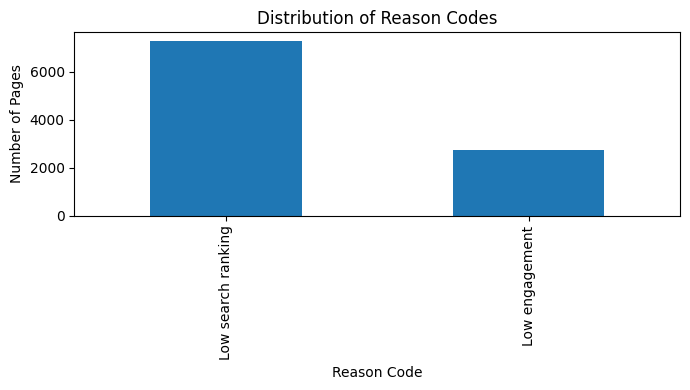

Export completed successfully!
CSV saved to: ../outputs/ranked_action_queue.csv
Figure saved to: ../figures/reason_code_distribution.png


In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from pathlib import Path
import matplotlib.pyplot as plt

# Create folders
Path("../outputs").mkdir(parents=True, exist_ok=True)
Path("../figures").mkdir(parents=True, exist_ok=True)

# Export ranked queue
queue.to_csv("../outputs/ranked_action_queue.csv", index=False)

# Create figure
plt.figure(figsize=(7,4))
queue["reason_code"].value_counts().plot(kind="bar")
plt.title("Distribution of Reason Codes")
plt.xlabel("Reason Code")
plt.ylabel("Number of Pages")
plt.tight_layout()

# Save figure
plt.savefig("../figures/reason_code_distribution.png")

plt.show()

print("Export completed successfully!")
print("CSV saved to: ../outputs/ranked_action_queue.csv")
print("Figure saved to: ../figures/reason_code_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.